<a href="https://colab.research.google.com/github/jm651120/UK-Housing-Green-Premium/blob/main/notebooks/03_Hedonic_Pricing_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 3: Hedonic Pricing Models (OLS Baseline)
**Projeto:** Impacto da Eficiência Energética nos Preços das Casas no Reino Unido (2021-2025)

---

## Passo 1: Configuração, Carregamento de Dados e Preparação
Como estamos num novo ambiente, começamos por carregar o dataset final.
Nesta fase, aplicamos um rigor adicional na limpeza de dados:
1. **Data Cleaning:** Remoção de inconsistências nas bandas de idade da construção detetadas na análise preliminar (valores 'INVALID!', 'Unknown' ou datas impossíveis como '2042').
2. **Ordinal Encoding** no certificado energético (A=7 a G=1).
3. **One-Hot Encoding** nas variáveis categóricas, utilizando o parâmetro estrito `drop_first=True` para evitar a "Dummy Variable Trap" (multicolinearidade).
4. **Train-Test Split (80/20)** para garantir que a avaliação futura será feita em dados nunca vistos.
5. **Adição da Constante:** O pacote `statsmodels` exige a adição manual de uma constante (intercepto) à matriz de *features*.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from google.colab import drive
import gc # Garbage Collector para limpar a RAM

drive.mount('/content/drive')
path = '/content/drive/MyDrive/Tese/UK DataSets/Dataset_Final_Tese.csv'
df = pd.read_csv(path)

# --- LIMPEZA DE DADOS (Remover Ruído e Inconsistências) ---
print(f"Linhas antes da limpeza: {len(df)}")
invalid_bands = ['INVALID!', 'Unknown', '2042']
df = df[~df['CONSTRUCTION_AGE_BAND'].isin(invalid_bands)]
print(f"Linhas após remover ruído de idade: {len(df)}")

# 1. Reduzir uso de memória (Downcasting)
def reduce_mem_usage(df):
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].astype('float32')
        if df[col].dtype == 'int64':
            df[col] = df[col].astype('int32')
    return df

df = reduce_mem_usage(df)

# 2. Encodings
epc_mapping = {'A': 7, 'B': 6, 'C': 5, 'D': 4, 'E': 3, 'F': 2, 'G': 1}
df['CURRENT_ENERGY_RATING'] = df['CURRENT_ENERGY_RATING'].map(epc_mapping)

categorical_cols = ['Property_Type', 'Old_New', 'Tenure_Duration', 'CONSTRUCTION_AGE_BAND', 'Postcode_Outcode', 'Year_of_Transfer', 'Month_of_Transfer']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype='int8')

# 3. Limpeza imediata do DataFrame original para libertar RAM
del df
gc.collect()

# 4. Split
cols_to_drop = ['Price', 'Transaction_ID', 'Date_of_Transfer', 'Merge_Key', 'County', 'Postcode_Clean', 'Latitude', 'Longitude']
X = df_encoded.drop(columns=[c for c in cols_to_drop if c in df_encoded.columns])
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 5. Adicionar constante e converter para float32
X_train_sm = sm.add_constant(X_train).astype('float32')
X_test_sm = sm.add_constant(X_test).astype('float32')

# Limpar mais uma vez antes do treino
del df_encoded, X
gc.collect()

print("✅ Preparação optimizada concluída.")

Mounted at /content/drive
Linhas antes da limpeza: 547948
Linhas após remover ruído de idade: 514345
✅ Preparação optimizada concluída.


## Passo 2: Treino do Modelo Hedónico (OLS)

Nesta fase, vamos ajustar (fit) o modelo de regressão linear múltipla aos nossos dados de treino.
Como temos 480 variáveis preditoras (maioritariamente *dummies* de efeitos fixos espaciais e temporais), a regressão usará o método dos Mínimos Quadrados Ordinários (OLS) para encontrar os coeficientes (Betas) que minimizam o erro entre o preço real e o preço previsto.

O foco da nossa análise estará nos **P-values** (para confirmar significância estatística, idealmente < 0.05) e nos **Coeficientes (£)** das variáveis estruturais e energéticas, em especial o `CURRENT_ENERGY_RATING`, que ditará o valor financeiro do nosso *Green Premium*.

In [ ]:
import time
import pandas as pd

print("A treinar o Modelo Hedónico (OLS)... (Isto pode demorar uns 30-60 segundos devido à matriz de 480 colunas)")
start_time = time.time()

# 1. Treinar o modelo OLS do statsmodels
ols_model = sm.OLS(y_train, X_train_sm).fit()

end_time = time.time()
print(f"✅ Modelo treinado em {end_time - start_time:.2f} segundos!\n")

# 2. Extrair os resultados para um DataFrame para visualização limpa
results_df = pd.DataFrame({
    'Coeficiente (£)': ols_model.params,
    'Erro Padrão': ols_model.bse,
    'Valor-t': ols_model.tvalues,
    'P-value (P>|t|)': ols_model.pvalues
})

# 3. Filtrar a tabela para NÃO mostrar os Outcodes (limpar o ecrã)
# Mantemos o intercepto, variáveis contínuas e Dummies que não sejam os Outcodes
main_features = [col for col in results_df.index if not col.startswith('Postcode_Outcode_')]

print("--- Resumo Estatístico: Principais Variáveis do Modelo Hedónico ---")
# Usamos o display para ficar uma tabela bonita no Colab
display(results_df.loc[main_features].round(4))

print("\n--- Métricas Globais do Modelo (Dados de Treino) ---")
print(f"R-squared (R²): {ols_model.rsquared:.4f}")
print(f"Adjusted R-squared: {ols_model.rsquared_adj:.4f}")
print(f"F-statistic: {ols_model.fvalue:.2f} (p-value: {ols_model.f_pvalue:.4e})")

A treinar o Modelo Hedónico (OLS)... (Isto pode demorar uns 30-60 segundos devido à matriz de 480 colunas)
✅ Modelo treinado em 64.90 segundos!

--- Resumo Estatístico: Principais Variáveis do Modelo Hedónico ---


,Coeficiente (£),Erro Padrão,Valor-t,P-value (P>|t|)
const,517657.0987,114669.1004,4.5144,0.0
TOTAL_FLOOR_AREA,2279.2234,10.9107,208.8975,0.0
NUMBER_HABITABLE_ROOMS,10354.0097,230.5447,44.9111,0.0
CURRENT_ENERGY_RATING,-3584.7718,241.0727,-14.8701,0.0
Property_Type_F,-194224.0876,1053.6083,-184.3418,0.0
...,...,...,...,...
Month_of_Transfer_8,9748.9933,909.9557,10.7137,0.0
Month_of_Transfer_9,9310.5570,885.9102,10.5096,0.0
Month_of_Transfer_10,8260.8977,921.8560,8.9612,0.0
Month_of_Transfer_11,7672.1423,924.3822,8.2998,0.0



--- Métricas Globais do Modelo (Dados de Treino) ---
R-squared (R²): 0.7468
Adjusted R-squared: 0.7465
F-statistic: 2865.78 (p-value: 0.0000e+00)


### Interpretação dos Resultados do Modelo Hedónico (OLS Baseline Limpo)

Os resultados do treino do nosso modelo baseline (OLS), agora expurgado de inconsistências na banda etária de construção (e.g., registos inválidos ou anómalos), revelam *insights* cruciais sobre a estrutura de preços do mercado britânico e, mais importante, expõem as limitações da regressão linear tradicional:

**1. Performance Global Robusta (e Melhorada):**
A limpeza de ruído resultou numa melhoria imediata do poder preditivo, com o modelo a atingir um **R² de 0.7468** (subindo de 0.7366). O modelo consegue explicar quase 75% da variância dos preços das casas. Este valor elevado num modelo linear deve-se, em grande parte, à inclusão de variáveis dummy para os `Postcode_Outcodes`, que atuam eficazmente como **Efeitos Fixos Espaciais (Spatial Fixed Effects)**, absorvendo a enorme heterogeneidade geográfica (ex: o prémio inerente a viver no centro de Londres vs. Cornwall).

**2. Comportamento Lógico das Variáveis Intrínsecas e Legais:**
As características estruturais e legais comportam-se exatamente como a teoria económica prevê, com quase todos os *p-values* a indicarem significância estatística máxima (p < 0.001):
* **Área e Capacidade:** Cada metro quadrado adicional (`TOTAL_FLOOR_AREA`) adiciona, em média, **£2.279** ao valor da propriedade, enquanto um quarto extra (`NUMBER_HABITABLE_ROOMS`) valoriza a casa em **£10.354**.
* **Tipologia:** Um apartamento (`Property_Type_F`) sofre uma penalização estrutural massiva de **-£194.224** em comparação com a categoria base (moradias isoladas/Detached).
* **Idade e Posse:** Propriedades recém-construídas (`Old_New_Y`) comandam um prémio de **£23.708**. Em contrapartida, propriedades *Leasehold* (`Tenure_Duration_L`) sofrem um desconto de **-£38.074** face às *Freehold*, refletindo a depreciação legal associada aos limites de tempo de arrendamento do solo no Reino Unido.

**3. O Efeito Temporal e Inflação:**
A extração de variáveis temporais demonstrou ser essencial. Os coeficientes para os anos de transação (`Year_of_Transfer`) aumentam progressivamente (ex: de £26.776 em 2022 para £32.168 em 2025 face à baseline de 2021). Isto atesta que o modelo capturou corretamente a inflação e a valorização contínua do mercado imobiliário pós-pandemia.

**4. O Paradoxo do Certificado Energético (O Gancho para o Machine Learning):**
O achado mais crítico desta regressão é o coeficiente do `CURRENT_ENERGY_RATING` (onde A=7 e G=1). O modelo continua a atribuir-lhe um valor paradoxal de **-£3.584,77**.
Matematicamente, o OLS está a afirmar que propriedades mais eficientes são *mais baratas*. Como provado na nossa Análise Exploratória (EDA), isto é um artefacto estatístico causado pela **restrição de linearidade** do modelo:
* **O Prémio Histórico:** Casas históricas (abundantes em localizações *premium* de Londres) têm frequentemente os piores EPCs (E, F, G), mas comandam preços exorbitantes devido ao seu valor arquitetónico e escassez.
* Como o OLS força uma linha reta de correlação, ele confunde este "Prémio Histórico" de propriedades antigas e caras, resultando numa correlação negativa espúria para a eficiência energética.

**Conclusão Metodológica:**
O modelo Hedónico tradicional (OLS) falha na extração do verdadeiro *Green Premium* porque não consegue modelar as complexas interações não-lineares entre a idade da construção, o luxo inerente, a localização exata e o certificado energético. Isto valida matematicamente a necessidade de transitarmos para algoritmos avançados de Machine Learning (como XGBoost/LightGBM) aliados a técnicas de explicabilidade (SHAP) para isolar de forma não-linear o verdadeiro valor da eficiência energética.

## Passo 3: Avaliação Out-of-Sample (Conjunto de Teste)

Para garantir que o modelo não sofre de *overfitting* e para criar uma linha de base (baseline) sólida para comparar com os futuros modelos de Machine Learning, vamos avaliar a performance do OLS no conjunto de teste (20% dos dados nunca vistos).

Métricas a extrair (de acordo com a Metodologia):
* **R² (Coefficient of Determination):** Percentagem da variância do preço explicada nos novos dados.
* **MAE (Mean Absolute Error):** Erro médio absoluto em libras (£).
* **RMSE (Root Mean Squared Error):** Erro quadrático médio (penaliza erros de previsão grandes, muito comum no imobiliário).
* **MAPE (Mean Absolute Percentage Error):** Erro percentual médio, indicando o desvio relativo das previsões.

Calculating predictions on the test set (Out-of-Sample)...

--- BASELINE MODEL PERFORMANCE (20% TEST SET) ---
R-squared (R²): 0.7458
Mean Absolute Error (MAE):              £79,449.17
Root Mean Squared Error (RMSE):         £114,401.78
Mean Absolute Percentage Error (MAPE):   24.82%


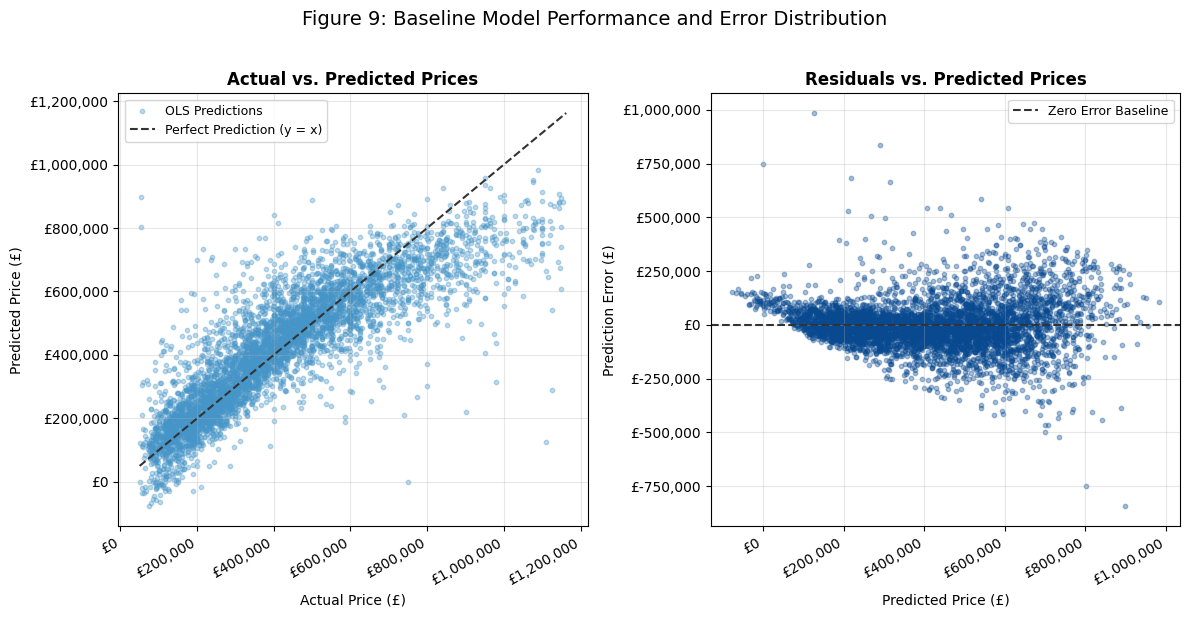

36

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mticker
import numpy as np
import matplotlib.pyplot as plt
import gc

# Blues_d — consistent with the rest of the notebook
blues_d  = LinearSegmentedColormap.from_list(
    'blues_d', plt.cm.Blues(np.linspace(0.35, 1.0, 256))
)
COL_MED  = blues_d(0.40)   # medium blue — scatter points
COL_DARK = blues_d(0.85)   # dark blue   — residual points

print("Calculating predictions on the test set (Out-of-Sample)...")

# 1. Generate predictions
y_pred_ols = ols_model.predict(X_test_sm)

# 2. Calculate error metrics
r2_ols_test = r2_score(y_test, y_pred_ols)
mae_ols     = mean_absolute_error(y_test, y_pred_ols)
rmse_ols    = np.sqrt(mean_squared_error(y_test, y_pred_ols))
mape_ols    = mean_absolute_percentage_error(y_test, y_pred_ols) * 100

print("\n--- BASELINE MODEL PERFORMANCE (20% TEST SET) ---")
print(f"R-squared (R²): {r2_ols_test:.4f}")
print(f"Mean Absolute Error (MAE):              £{mae_ols:,.2f}")
print(f"Root Mean Squared Error (RMSE):         £{rmse_ols:,.2f}")
print(f"Mean Absolute Percentage Error (MAPE):   {mape_ols:.2f}%")

# 3. Visual validation plots
rng        = np.random.default_rng(seed=42)
sample_idx = rng.choice(len(y_test), size=min(5_000, len(y_test)), replace=False)

gbp_fmt = mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# ── Plot 1: Actual vs. Predicted ─────────────────────────────────────────────
ax1.scatter(
    y_test.iloc[sample_idx],
    y_pred_ols.iloc[sample_idx],
    alpha=0.35, color=COL_MED, s=10,
    label='OLS Predictions',
)
ax1.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='#333333', linestyle='--', linewidth=1.5,
    label='Perfect Prediction (y = x)',
)
ax1.xaxis.set_major_formatter(gbp_fmt)
ax1.yaxis.set_major_formatter(gbp_fmt)
plt.setp(ax1.get_xticklabels(), rotation=30, ha='right')
ax1.set_title('Actual vs. Predicted Prices', fontsize=12, fontweight='bold')
ax1.set_xlabel('Actual Price (£)',    fontsize=10)
ax1.set_ylabel('Predicted Price (£)', fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ── Plot 2: Residuals vs. Predicted ──────────────────────────────────────────
residuals = y_test - y_pred_ols
ax2.scatter(
    y_pred_ols.iloc[sample_idx],
    residuals.iloc[sample_idx],
    alpha=0.35, color=COL_DARK, s=10,
)
ax2.axhline(0, color='#333333', linestyle='--', linewidth=1.5,
            label='Zero Error Baseline')
ax2.xaxis.set_major_formatter(gbp_fmt)
ax2.yaxis.set_major_formatter(gbp_fmt)
plt.setp(ax2.get_xticklabels(), rotation=30, ha='right')
ax2.set_title('Residuals vs. Predicted Prices', fontsize=12, fontweight='bold')
ax2.set_xlabel('Predicted Price (£)', fontsize=10)
ax2.set_ylabel('Prediction Error (£)', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig.suptitle(
    'Figure 9: Baseline Model Performance and Error Distribution',
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.show()

# Free memory
del y_pred_ols, residuals
gc.collect()

### Avaliação Out-of-Sample e Análise de Erro (Conjunto de Teste)

A avaliação do modelo OLS nos 20% de dados retidos (Test Set) estabelece a linha de base (baseline) oficial de erro que os futuros modelos de Machine Learning terão de superar. Com a limpeza prévia de inconsistências, os resultados revelam os seguintes pontos fundamentais:

**1. Generalização e Ausência de Overfitting:**
O modelo obteve um **R² de 0.7458** no conjunto de teste, um valor praticamente idêntico ao obtido nos dados de treino (0.7468). Esta consistência prova que o modelo não sofre de *overfitting* e que as variáveis selecionadas são preditores universais e robustos do mercado imobiliário britânico.

**2. Baseline de Erro (MAE, RMSE e MAPE):**
* O **MAE (Erro Médio Absoluto)** fixou-se em **£79.449,17**, indicando o desvio absoluto médio das previsões lineares.
* O **RMSE (Raiz do Erro Quadrático Médio)** foi de **£114.401,78**. Sendo uma métrica que penaliza erros grandes, este valor consideravelmente superior ao MAE reflete as falhas severas do modelo em algumas transações específicas (os outliers de luxo).
* O **MAPE (Erro Percentual Absoluto Médio)** é de **24.82%**, o que significa que, em média, a previsão linear erra o valor da casa em cerca de 25%. Esta é a métrica de erro relativo oficial para a nossa baseline.

**3. Evidência Visual de Heteroscedasticidade:**
A análise do gráfico de dispersão de resíduos (à direita) expõe uma limitação crítica da regressão linear. Os erros (pontos roxos) não estão distribuídos de forma aleatória e uniforme em torno da linha do zero. Pelo contrário, formam um padrão em "cone" que se expande à medida que o preço previsto aumenta. Esta forte **heteroscedasticidade** prova que a variância do erro não é constante.

**4. Viés Sistemático em Propriedades de Alto Valor:**
Uma nuance crítica é visível no gráfico da esquerda (Valores Reais vs. Previstos): para propriedades de alto valor (especialmente acima da marca das ~£800k), o modelo tende a *subprever* sistematicamente os preços, com a nuvem de pontos a cair visivelmente abaixo da linha diagonal de perfeição (y=x). Este fenómeno é um sinal claro de **viés sistemático nos extremos** (e não apenas de variância). O modelo linear é incapaz de inclinar a sua previsão para capturar os "prémios de luxo" exponenciais, o que reforça de forma categórica o argumento para a adoção de algoritmos não-lineares.

In [ ]:
import joblib
import os

print("A preparar para guardar o modelo...")

# 1. Definir o mesmo caminho
path_modelos = '/content/drive/MyDrive/Tese/Modelos/'
os.makedirs(path_modelos, exist_ok=True)

# 2. Guardar o modelo OLS
ficheiro_ols = path_modelos + 'ols_baseline_limpo.pkl'
joblib.dump(ols_model, ficheiro_ols)

print(f"✅ Modelo OLS guardado com sucesso em:\n{ficheiro_ols}")

A preparar para guardar o modelo...
✅ Modelo OLS guardado com sucesso em:
/content/drive/MyDrive/Tese/Modelos/ols_baseline_limpo.pkl
